In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("worldbank_inflation_model_ready.csv")
print("Shape:", df.shape)

Shape: (240, 70)


# Basic Information

In [3]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,4.032258,4.032258,4.032258,4.032258,4.032258,4.032258,...,-0.931196,-1.028282,3.626041,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462,4.257462
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,19.598394,19.598394,19.598394,19.598394,19.598394,19.598394,...,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,4.270111
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,12.686269,12.686269,12.686269,12.686269,12.686269,12.686269,...,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,-6.601186
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,8.799211,8.799211,8.799211,8.799211,8.799211,8.799211,...,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,1.657818
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,83.783784,83.783784,83.783784,83.783784,83.783784,83.783784,...,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,20.162020


In [4]:
df.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
235,Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,-1.084813,-1.084813,-1.084813,-1.084813,-1.084813,-1.084813,...,0.273169,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,1.619450,3.859539
236,"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726,8.104726
237,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288877,2.102351,1.246275,1.337971,2.534989,4.069019,...,6.602908,5.186187,4.509873,4.102851,3.232388,4.618745,7.039873,6.075244,4.361152,3.205505
238,Zambia,ZMB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,55.828221,55.828221,55.828221,55.828221,55.828221,55.828221,...,17.869730,6.577312,7.494572,9.150316,15.733060,22.020768,10.993204,10.884532,14.985626,13.909910
239,Zimbabwe,ZWE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,3.022670,3.022670,3.022670,3.022670,3.022670,3.022670,...,-1.543670,0.893962,10.618866,255.304991,557.201817,98.546105,104.705171,104.705171,104.705171,104.705171


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    240 non-null    object 
 1   Country Code    240 non-null    object 
 2   Indicator Name  240 non-null    object 
 3   Indicator Code  240 non-null    object 
 4   1960            240 non-null    float64
 5   1961            240 non-null    float64
 6   1962            240 non-null    float64
 7   1963            240 non-null    float64
 8   1964            240 non-null    float64
 9   1965            240 non-null    float64
 10  1966            240 non-null    float64
 11  1967            240 non-null    float64
 12  1968            240 non-null    float64
 13  1969            240 non-null    float64
 14  1970            240 non-null    float64
 15  1971            240 non-null    float64
 16  1972            240 non-null    float64
 17  1973            240 non-null    flo

In [6]:
df.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,...,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,80.698295,80.659094,81.018111,81.367579,81.452561,82.044625,85.894532,81.191739,81.581977,80.817304,...,6.238867,5.855887,5.240201,6.023814,7.742303,8.432999,12.383548,11.007358,8.438843,7.432080
std,419.672012,419.670187,419.681197,419.640624,419.587042,419.877898,425.050563,419.655964,419.653491,419.633560,...,29.905378,20.714570,17.937460,24.371126,41.166253,30.750198,23.306226,26.056986,25.524647,25.086758
min,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,-17.640424,...,-3.078218,-1.537100,-2.814698,-3.233389,-2.540315,-0.772844,-6.687321,-4.644709,-6.601186,-6.601186
25%,1.791526,2.070528,2.126064,2.329304,2.849670,2.631579,3.046391,2.189239,2.356131,2.687652,...,0.400659,1.381459,1.523435,1.102962,0.598986,2.264515,5.630727,3.814167,2.126158,1.766465
50%,5.705755,5.828232,5.690739,5.828232,5.845391,5.586299,6.155172,5.639482,5.639482,5.970155,...,1.652140,2.441511,2.534454,2.216776,2.147979,3.635086,8.095126,5.877227,3.174228,3.079932
75%,11.759787,11.913472,11.672852,11.986980,12.032246,12.032246,12.032246,11.913472,11.913472,11.913472,...,4.449720,4.584646,4.002077,3.478965,3.769736,5.338531,10.964253,8.512644,4.672331,4.260624
max,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,4734.914347,...,379.999586,254.948535,254.948535,255.304991,557.201817,359.093041,254.948535,254.948535,254.948535,254.948535


# Year Identification

In [7]:
year_cols = [
    col for col in df.columns
    if str(col).isdigit()
]

print("Number of years:", len(year_cols))
print("First year:", year_cols[0])
print("Last year:", year_cols[-1])

Number of years: 66
First year: 1960
Last year: 2025


# Inflation statistics

In [8]:
inflation_values = df[year_cols].values.flatten()

inflation_values = inflation_values[
    ~np.isnan(inflation_values)
]

print("Minimum inflation:", inflation_values.min())
print("Maximum inflation:", inflation_values.max())
print("Mean inflation:", inflation_values.mean())
print("Median inflation:", np.median(inflation_values))
print("Standard deviation:", inflation_values.std())

Minimum inflation: -17.6404240920371
Maximum inflation: 23773.1317741016
Mean inflation: 53.51089989884083
Median inflation: 5.67499999999992
Standard deviation: 383.42348469996034


# Inflation Distribution

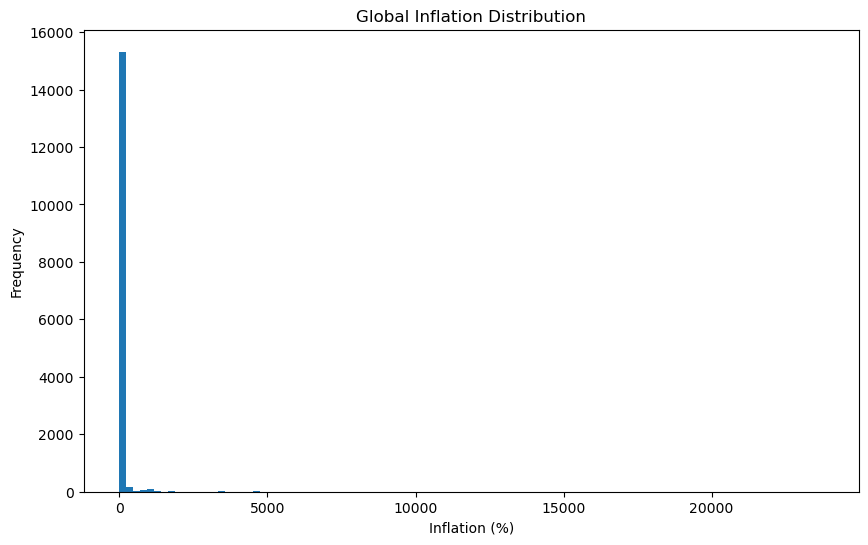

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    inflation_values,
    bins=100
)

plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("Global Inflation Distribution")

plt.show()

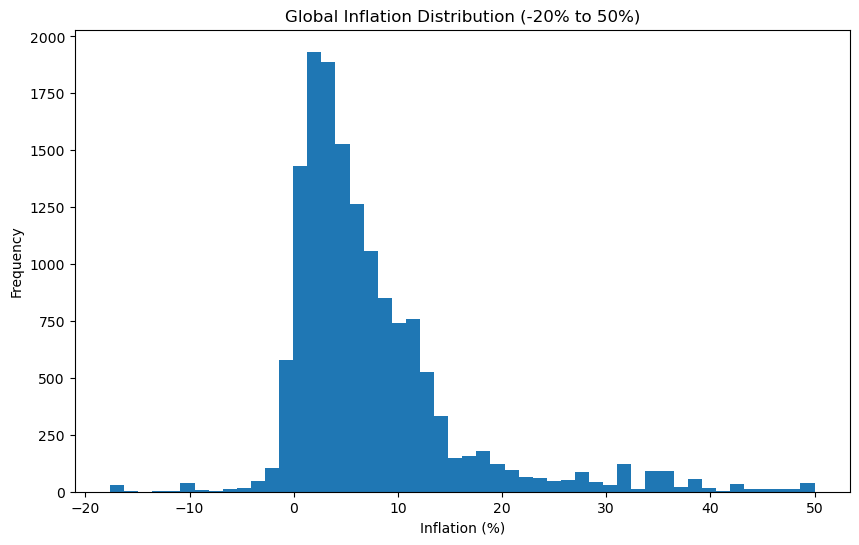

In [10]:
normal_inflation = inflation_values[
    (inflation_values >= -20) &
    (inflation_values <= 50)
]

plt.figure(figsize=(10, 6))

plt.hist(
    normal_inflation,
    bins=50
)

plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.title("Global Inflation Distribution (-20% to 50%)")

plt.show()

# Global Avg Inflation per year

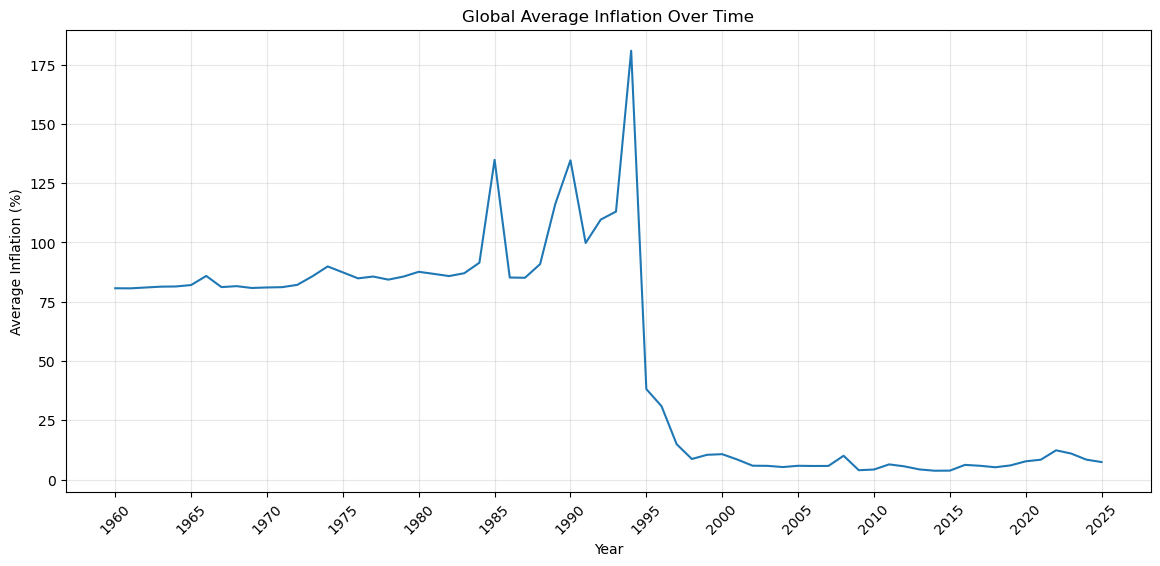

In [11]:
global_average = df[year_cols].mean()

plt.figure(figsize=(14, 6))

plt.plot(
    global_average.index,
    global_average.values
)

plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")
plt.title("Global Average Inflation Over Time")

plt.xticks(
    range(0, len(year_cols), 5),
    year_cols[::5],
    rotation=45
)

plt.grid(alpha=0.3)

plt.show()

# Global median inflation per year

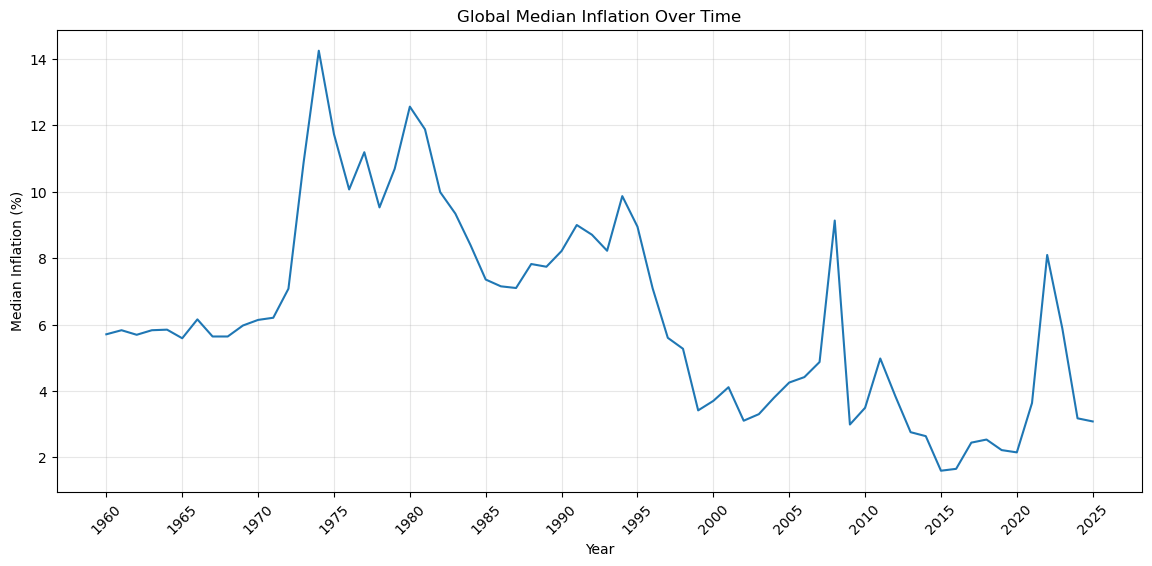

In [12]:
global_median = df[year_cols].median()

plt.figure(figsize=(14, 6))

plt.plot(
    global_median.index,
    global_median.values
)

plt.xlabel("Year")
plt.ylabel("Median Inflation (%)")
plt.title("Global Median Inflation Over Time")

plt.xticks(
    range(0, len(year_cols), 5),
    year_cols[::5],
    rotation=45
)

plt.grid(alpha=0.3)

plt.show()

# Highest inflation countries

In [13]:
long_df = df.melt(
    id_vars=[
        "Country Name",
        "Country Code"
    ],
    value_vars=year_cols,
    var_name="Year",
    value_name="Inflation"
)

long_df["Year"] = long_df["Year"].astype(int)

print(long_df.head())

                  Country Name Country Code  Year  Inflation
0                        Aruba          ABW  1960   4.032258
1  Africa Eastern and Southern          AFE  1960  19.598394
2                  Afghanistan          AFG  1960  12.686269
3   Africa Western and Central          AFW  1960   8.799211
4                       Angola          AGO  1960  83.783784


In [14]:
highest = (
    long_df
    .sort_values("Inflation", ascending=False)
    .head(20)
)

print(highest)

          Country Name Country Code  Year     Inflation
8199  Congo, Dem. Rep.          COD  1994  23773.131774
6025           Bolivia          BOL  1985  11749.639632
7368              Peru          PER  1990   7481.663611
4304           Ukraine          UKR  1977   4734.914347
1424           Ukraine          UKR  1965   4734.914347
1664           Ukraine          UKR  1966   4734.914347
4784           Ukraine          UKR  1979   4734.914347
2624           Ukraine          UKR  1970   4734.914347
7664           Ukraine          UKR  1991   4734.914347
3824           Ukraine          UKR  1975   4734.914347
5504           Ukraine          UKR  1982   4734.914347
5264           Ukraine          UKR  1981   4734.914347
2864           Ukraine          UKR  1971   4734.914347
5984           Ukraine          UKR  1984   4734.914347
4064           Ukraine          UKR  1976   4734.914347
6464           Ukraine          UKR  1986   4734.914347
4544           Ukraine          UKR  1978   4734

# Lowest inflation observations

In [15]:
lowest = (
    long_df
    .sort_values("Inflation")
    .head(20)
)

print(lowest)

           Country Name Country Code  Year  Inflation
1759  Equatorial Guinea          GNQ  1967 -17.640424
5119  Equatorial Guinea          GNQ  1981 -17.640424
6319  Equatorial Guinea          GNQ  1986 -17.640424
3439  Equatorial Guinea          GNQ  1974 -17.640424
4639  Equatorial Guinea          GNQ  1979 -17.640424
3199  Equatorial Guinea          GNQ  1973 -17.640424
5599  Equatorial Guinea          GNQ  1983 -17.640424
4399  Equatorial Guinea          GNQ  1978 -17.640424
1999  Equatorial Guinea          GNQ  1968 -17.640424
319   Equatorial Guinea          GNQ  1961 -17.640424
2959  Equatorial Guinea          GNQ  1972 -17.640424
559   Equatorial Guinea          GNQ  1962 -17.640424
5359  Equatorial Guinea          GNQ  1982 -17.640424
2719  Equatorial Guinea          GNQ  1971 -17.640424
4879  Equatorial Guinea          GNQ  1980 -17.640424
4159  Equatorial Guinea          GNQ  1977 -17.640424
2239  Equatorial Guinea          GNQ  1969 -17.640424
79    Equatorial Guinea     

# Top 10 countries by average inflation

In [16]:
country_average = (
    df.set_index("Country Name")[year_cols]
    .mean(axis=1)
    .sort_values(ascending=False)
)

print(country_average.head(10))

Country Name
Ukraine                                          2465.246131
Armenia                                          1793.816644
Kazakhstan                                       1002.829291
Belarus                                           674.239268
Moldova                                           550.624369
Congo, Dem. Rep.                                  545.271847
Lithuania                                         520.151343
Latvia                                            480.559721
Europe & Central Asia (excluding high income)     478.822663
Russian Federation                                464.553991
dtype: float64


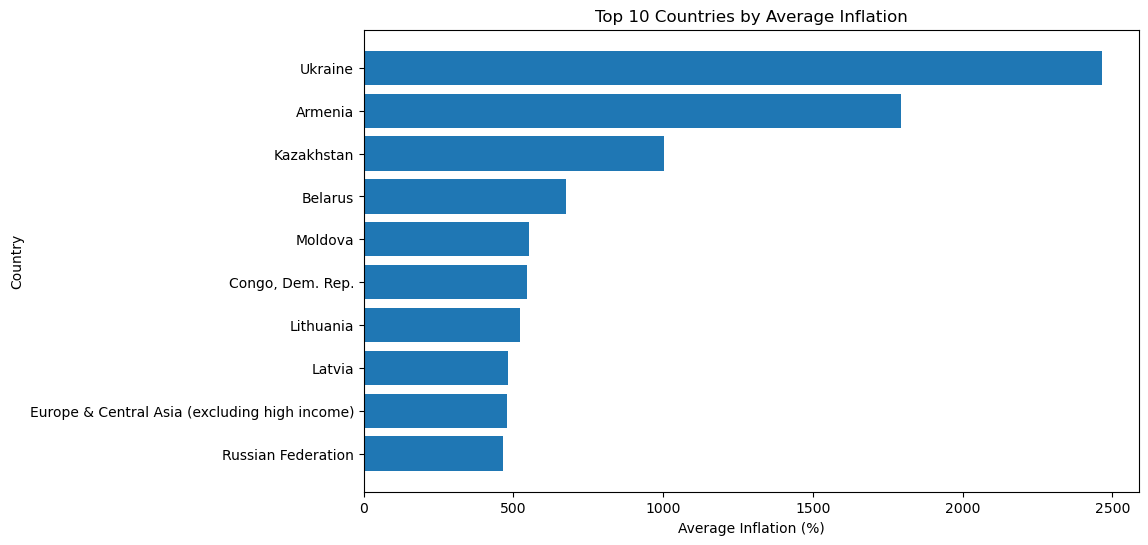

In [17]:
top10 = country_average.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10.values
)

plt.xlabel("Average Inflation (%)")
plt.ylabel("Country")
plt.title("Top 10 Countries by Average Inflation")

plt.show()

# Lowest average inflation

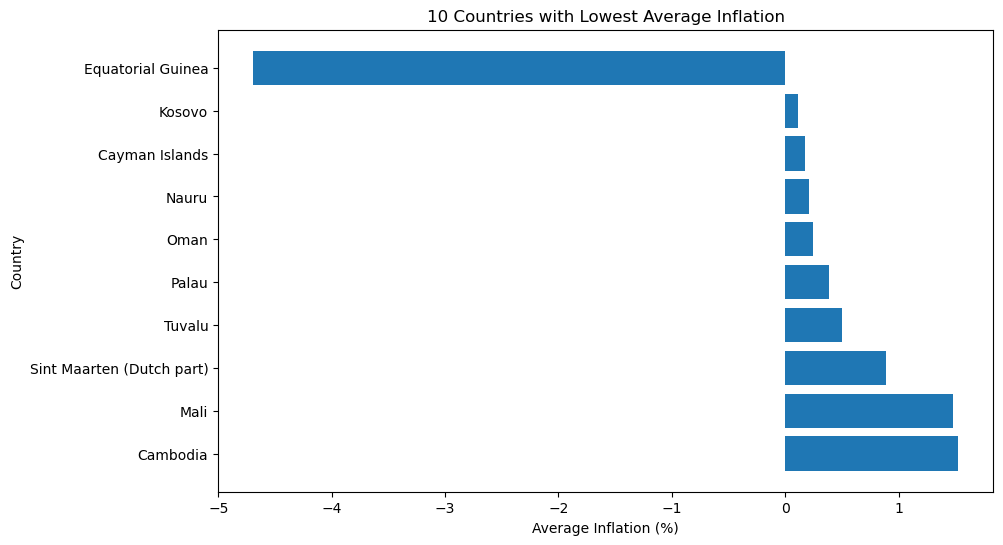

In [18]:
bottom10 = (
    country_average
    .sort_values()
    .head(10)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    bottom10.index,
    bottom10.values
)

plt.xlabel("Average Inflation (%)")
plt.ylabel("Country")
plt.title("10 Countries with Lowest Average Inflation")

plt.show()

# Inflation volatility by country

In [19]:
country_volatility = (
    df.set_index("Country Name")[year_cols]
    .std(axis=1)
    .sort_values(ascending=False)
)

print(country_volatility.head(10))

Country Name
Congo, Dem. Rep.    2967.292365
Ukraine             2360.244805
Armenia             1691.779274
Bolivia             1450.651709
Peru                1004.181649
Kazakhstan           936.604078
Angola               617.788703
Belarus              604.351087
Brazil               522.372201
Moldova              520.812670
dtype: float64


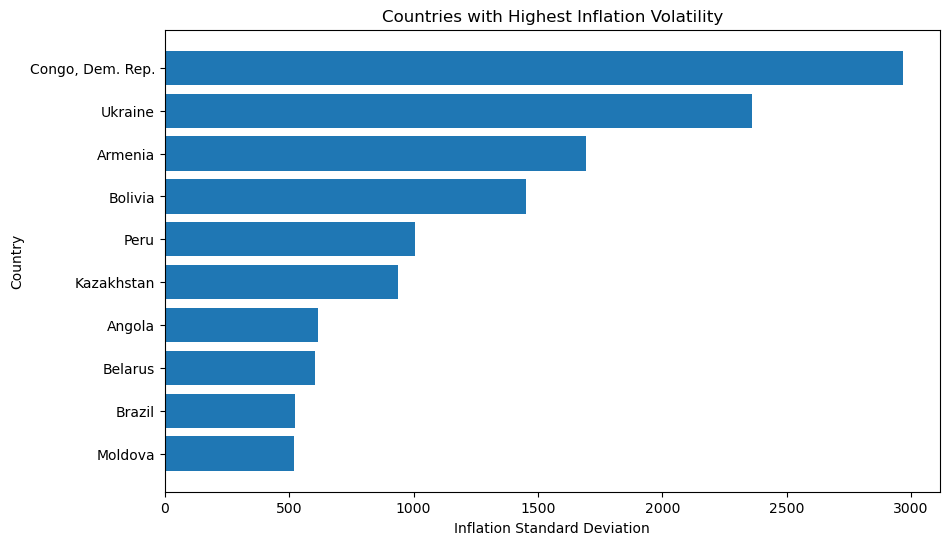

In [20]:
top_volatility = (
    country_volatility
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_volatility.index,
    top_volatility.values
)

plt.xlabel("Inflation Standard Deviation")
plt.ylabel("Country")
plt.title("Countries with Highest Inflation Volatility")

plt.show()

# Select individual countries

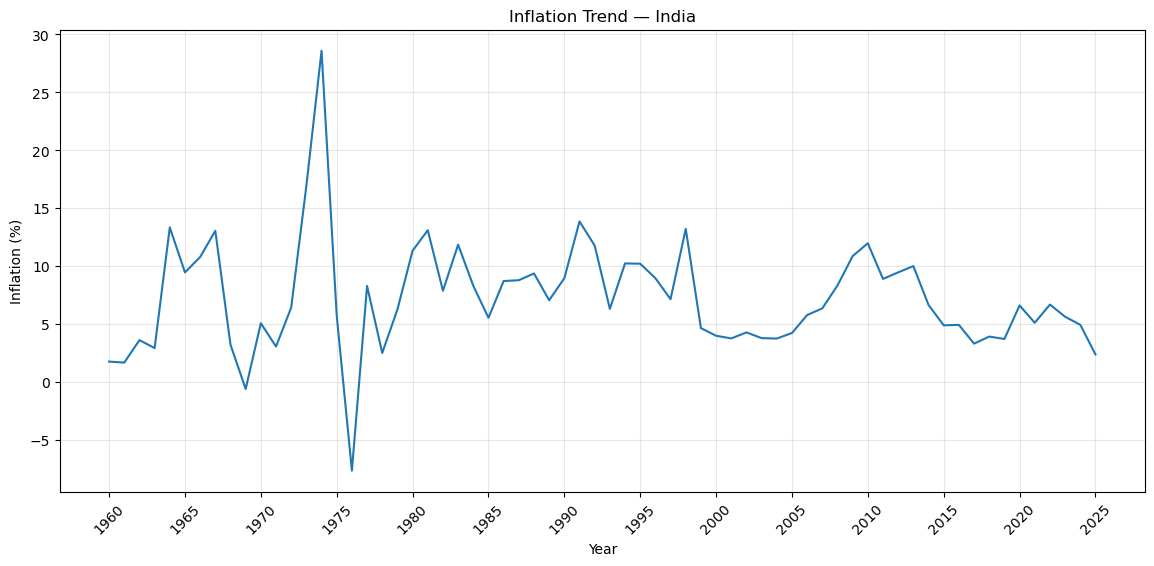

In [21]:
country = "India"

india = df[
    df["Country Name"] == country
]

india_values = india[year_cols].iloc[0]

plt.figure(figsize=(14, 6))

plt.plot(
    year_cols,
    india_values
)

plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.title(f"Inflation Trend — {country}")

plt.xticks(
    range(0, len(year_cols), 5),
    year_cols[::5],
    rotation=45
)

plt.grid(alpha=0.3)

plt.show()

# Compare multiple countries

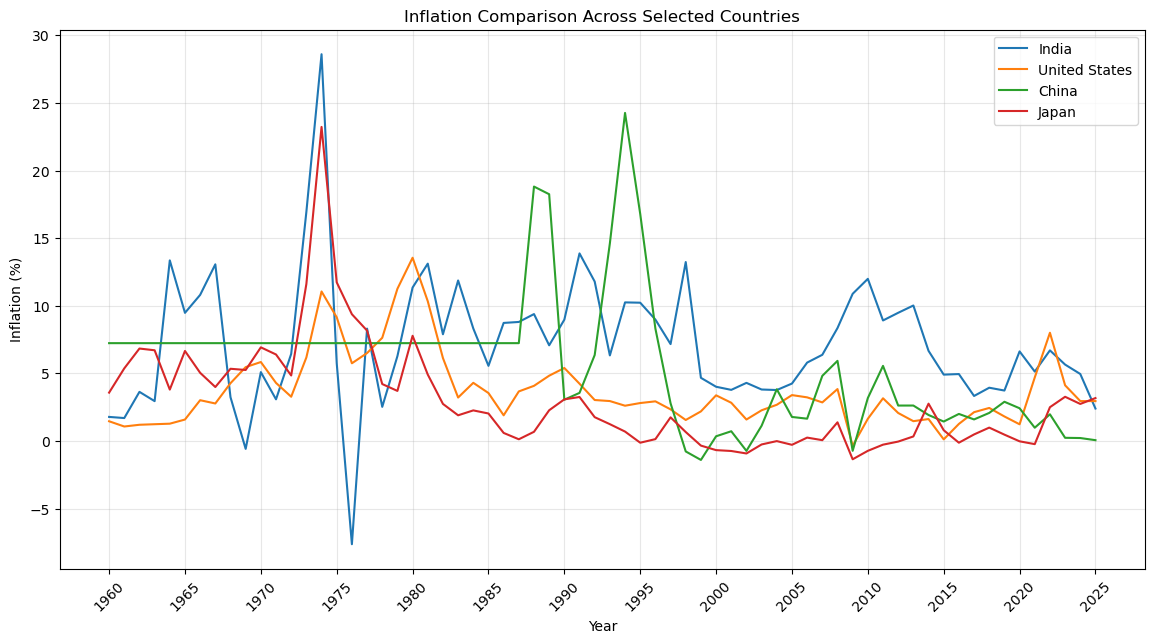

In [22]:
countries = [
    "India",
    "United States",
    "China",
    "Japan"
]

plt.figure(figsize=(14, 7))

for country in countries:

    row = df[
        df["Country Name"] == country
    ]

    if not row.empty:

        values = row[year_cols].iloc[0]

        plt.plot(
            year_cols,
            values,
            label=country
        )

plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.title("Inflation Comparison Across Selected Countries")

plt.xticks(
    range(0, len(year_cols), 5),
    year_cols[::5],
    rotation=45
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Inflation during recent global events

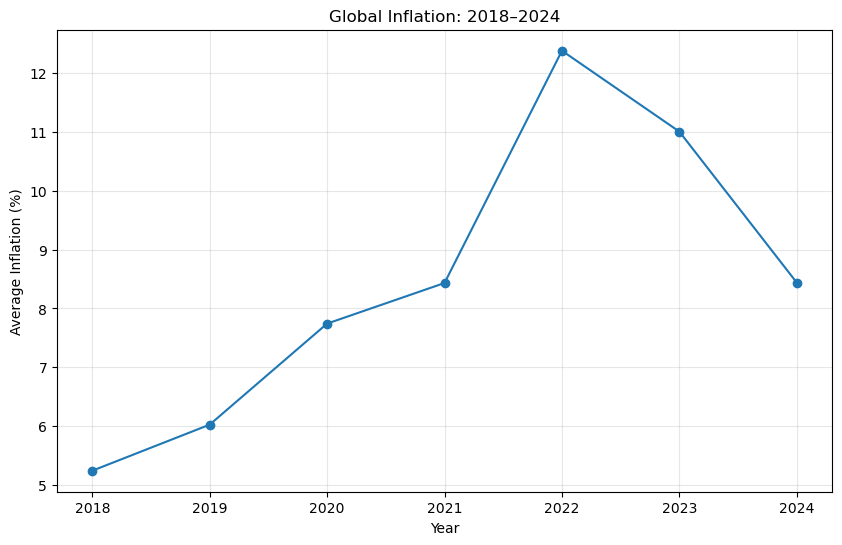

In [23]:
recent_years = [
    str(year)
    for year in range(2018, 2025)
]

recent_global = df[recent_years].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    recent_global.index,
    recent_global.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")
plt.title("Global Inflation: 2018–2024")

plt.grid(alpha=0.3)

plt.show()

# Highest inflation each year

In [24]:
yearly_max = df[year_cols].max()

yearly_max_country = []

for year in year_cols:

    idx = df[year].idxmax()

    yearly_max_country.append({
        "Year": int(year),
        "Country": df.loc[idx, "Country Name"],
        "Inflation": df.loc[idx, year]
    })

yearly_max_country = pd.DataFrame(
    yearly_max_country
)

print(yearly_max_country)

    Year        Country    Inflation
0   1960        Ukraine  4734.914347
1   1961        Ukraine  4734.914347
2   1962        Ukraine  4734.914347
3   1963        Ukraine  4734.914347
4   1964        Ukraine  4734.914347
..   ...            ...          ...
61  2021          Sudan   359.093041
62  2022  Venezuela, RB   254.948535
63  2023  Venezuela, RB   254.948535
64  2024  Venezuela, RB   254.948535
65  2025  Venezuela, RB   254.948535

[66 rows x 3 columns]


# Lowest inflation each year

In [25]:
yearly_min_country = []

for year in year_cols:

    idx = df[year].idxmin()

    yearly_min_country.append({
        "Year": int(year),
        "Country": df.loc[idx, "Country Name"],
        "Inflation": df.loc[idx, year]
    })

yearly_min_country = pd.DataFrame(
    yearly_min_country
)

print(yearly_min_country)

    Year            Country  Inflation
0   1960  Equatorial Guinea -17.640424
1   1961  Equatorial Guinea -17.640424
2   1962  Equatorial Guinea -17.640424
3   1963  Equatorial Guinea -17.640424
4   1964  Equatorial Guinea -17.640424
..   ...                ...        ...
61  2021               Chad  -0.772844
62  2022        South Sudan  -6.687321
63  2023        Afghanistan  -4.644709
64  2024        Afghanistan  -6.601186
65  2025        Afghanistan  -6.601186

[66 rows x 3 columns]


# Finishing up

In [26]:
long_df.to_csv(
    "worldbank_inflation_long.csv",
    index=False
)

print("Long-format dataset saved!")

Long-format dataset saved!
